# Assignment 2: Data Privacy and AI  
## Homomorphic Encryption + Logistic Regression Prototype

This notebook implements a privacy-preserving AI workflow for the assignment.  
It compares a plaintext baseline model with a Paillier-based homomorphic encryption prototype.


## 1. Import libraries

This cell imports all libraries needed for data handling, preprocessing, modeling, encryption, evaluation, and visualization.

In [7]:
import os
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from phe import paillier

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

warnings.filterwarnings("ignore")

# Create folders for outputs
os.makedirs("figures", exist_ok=True)
os.makedirs("outputs", exist_ok=True)

## 2. Load the dataset

This cell loads the assignment dataset.  
Replace the file path only if your CSV file is stored in a different folder.

In [8]:
file_path = "Assignment2Dataset-1.csv"
df_raw = pd.read_csv(file_path)

print("Original shape:", df_raw.shape)
display(df_raw.head())

Original shape: (60, 40)


,Name,Country,SSN,DOB,Income,Sex,Marital Status,Education,Loan,House Status,...,Unnamed: 30,Unnamed: 31,Unnamed: 32,Unnamed: 33,Unnamed: 34,Unnamed: 35,Unnamed: 36,Unnamed: 37,Unnamed: 38,Unnamed: 39
0,John Smith,USA,123-45-6789,7/15/1985,50000,Male,Married,Bachelor's Degree,Yes,Own,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Emily Johnson,Canada,987-65-4321,12/2/1990,60000,Female,Single,Master's Degree,No,Rent,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Michael Davis,UK,456-78-9123,3/20/1978,75000,Male,Divorced,High School Diploma,Yes,Own,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Jessica Martinez,Australia,789-12-3456,9/10/1982,40000,Female,Married,Associate's Degree,No,Own,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,David Thompson,USA,234-56-7890,6/25/1995,35000,Male,Single,Some College,No,Rent,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Clean the dataset structure

The uploaded dataset contains many empty `Unnamed` columns.  
This cell removes those columns so only the meaningful fields remain.

In [9]:
df = df_raw.loc[:, ~df_raw.columns.str.contains("^Unnamed")].copy()

print("Cleaned shape:", df.shape)
print("Columns:")
print(df.columns.tolist())

Cleaned shape: (60, 20)
Columns:
['Name', 'Country', 'SSN', 'DOB', 'Income', 'Sex', 'Marital Status', 'Education', 'Loan', 'House Status', 'Blood Type', 'Blood Pressure', 'Heart Rate', 'Oxygen Level', 'Medical Procedure', 'Smoking', 'Alcohol Consumption', 'Allergies', 'Vaccinations', 'Tumor Condition']


## 4. Check missing values and target distribution

This step gives a quick understanding of data quality and class balance before preprocessing.

In [10]:
print("Missing values by column:")
display(df.isna().sum().sort_values(ascending=False))

print("\nTarget distribution:")
display(df["Tumor Condition"].value_counts(dropna=False))

Missing values by column:


,0
Tumor Condition,2
Vaccinations,2
Allergies,2
Alcohol Consumption,2
Smoking,2
Oxygen Level,1
Medical Procedure,1
Heart Rate,1
DOB,0
SSN,0



Target distribution:


,count
Tumor Condition,
Normal,48
Abnormal,10
NaN,2


## 5. Visualize the tumor class distribution

This figure can be used directly in the report to show the class imbalance in the target variable.

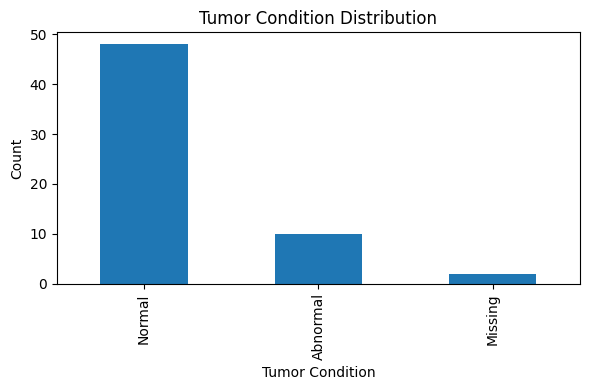

In [11]:
target_counts = df["Tumor Condition"].fillna("Missing").value_counts()

plt.figure(figsize=(6, 4))
target_counts.plot(kind="bar")
plt.title("Tumor Condition Distribution")
plt.xlabel("Tumor Condition")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("figures/figure_1_target_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

## 6. Engineer usable medical and demographic features

Some columns need conversion before modeling:
- `DOB` is converted into `Age`
- `Oxygen Level` is converted from strings like `98%` into numeric form
- `Blood Pressure` is split into systolic and diastolic values

Direct identifiers such as `Name` and `SSN` are removed from the model features.

In [12]:
class MedicalFeatureEngineer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()

        # Convert DOB to age
        dob = pd.to_datetime(X["DOB"], errors="coerce")
        reference_date = pd.Timestamp("2026-01-01")
        X["Age"] = ((reference_date - dob).dt.days / 365.25).round(1)

        # Convert oxygen level from text to numeric
        X["Oxygen Level Numeric"] = (
            X["Oxygen Level"]
            .astype(str)
            .str.replace("%", "", regex=False)
            .replace("nan", np.nan)
        )
        X["Oxygen Level Numeric"] = pd.to_numeric(X["Oxygen Level Numeric"], errors="coerce")

        # Split blood pressure
        bp = X["Blood Pressure"].astype(str).str.split("/", expand=True)
        X["Systolic BP"] = pd.to_numeric(bp[0], errors="coerce")
        X["Diastolic BP"] = pd.to_numeric(bp[1], errors="coerce")

        # Drop direct identifiers and raw columns already transformed
        X = X.drop(columns=["Name", "SSN", "DOB", "Blood Pressure", "Oxygen Level"])

        return X

feature_engineer = MedicalFeatureEngineer()
df_model = feature_engineer.fit_transform(df)

print("Engineered dataset shape:", df_model.shape)
display(df_model.head())

Engineered dataset shape: (60, 19)


,Country,Income,Sex,Marital Status,Education,Loan,House Status,Blood Type,Heart Rate,Medical Procedure,Smoking,Alcohol Consumption,Allergies,Vaccinations,Tumor Condition,Age,Oxygen Level Numeric,Systolic BP,Diastolic BP
0,USA,50000,Male,Married,Bachelor's Degree,Yes,Own,O+,72.0,Appendectomy,No,No,Pollen,Yes,Normal,40.5,98.0,120,80.0
1,Canada,60000,Female,Single,Master's Degree,No,Rent,A-,68.0,Laser Eye Surgery,No,Yes,Shellfish,No,Normal,35.1,96.0,110,70.0
2,UK,75000,Male,Divorced,High School Diploma,Yes,Own,B+,75.0,Colonoscopy,No,Yes,Cats,Yes,Abnormal,47.8,97.0,130,85.0
3,Australia,40000,Female,Married,Associate's Degree,No,Own,AB-,70.0,Mammogram,No,No,Dust,No,Normal,43.3,99.0,115,75.0
4,USA,35000,Male,Single,Some College,No,Rent,O-,68.0,Dental Cleaning,Yes,Yes,Peanuts,Yes,Normal,30.5,97.0,125,80.0


## 7. Define features and target

The target variable is converted into binary form:
- `Abnormal` = 1
- `Normal` = 0

In [13]:
target_col = "Tumor Condition"

df_model[target_col] = df_model[target_col].fillna(df_model[target_col].mode()[0])
y = (df_model[target_col] == "Abnormal").astype(int)

X = df_model.drop(columns=[target_col])

numeric_cols = [
    "Income",
    "Heart Rate",
    "Age",
    "Oxygen Level Numeric",
    "Systolic BP",
    "Diastolic BP"
]
categorical_cols = [col for col in X.columns if col not in numeric_cols]

print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)
print("\nTarget counts:")
print(y.value_counts())

Numeric columns: ['Income', 'Heart Rate', 'Age', 'Oxygen Level Numeric', 'Systolic BP', 'Diastolic BP']
Categorical columns: ['Country', 'Sex', 'Marital Status', 'Education', 'Loan', 'House Status', 'Blood Type', 'Medical Procedure', 'Smoking', 'Alcohol Consumption', 'Allergies', 'Vaccinations']

Target counts:
Tumor Condition
0    50
1    10
Name: count, dtype: int64


## 8. Build the preprocessing pipeline

Numeric columns are imputed with the median and standardized.  
Categorical columns are imputed with the most frequent value and then one-hot encoded.

In [14]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_cols),
    ("cat", categorical_transformer, categorical_cols)
])

## 9. Split the data into training and testing sets

A stratified split is used so the abnormal/normal class ratio is preserved in both sets.

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

Training set shape: (45, 18)
Test set shape: (15, 18)


## 10. Apply preprocessing

This step transforms the data into a machine-learning-ready matrix.

In [16]:
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)

ohe = preprocessor.named_transformers_["cat"].named_steps["onehot"]
feature_names = numeric_cols + ohe.get_feature_names_out(categorical_cols).tolist()

X_train_proc = np.asarray(X_train_proc, dtype=float)
X_test_proc = np.asarray(X_test_proc, dtype=float)

print("Processed training shape:", X_train_proc.shape)
print("Processed test shape:", X_test_proc.shape)
print("Total engineered features:", len(feature_names))
print("\nFirst 15 feature names:")
print(feature_names[:15])

Processed training shape: (45, 58)
Processed test shape: (15, 58)
Total engineered features: 58

First 15 feature names:
['Income', 'Heart Rate', 'Age', 'Oxygen Level Numeric', 'Systolic BP', 'Diastolic BP', 'Country_Australia', 'Country_Canada', 'Country_UK', 'Country_USA', 'Sex_Female', 'Sex_Male', 'Marital Status_Divorced', 'Marital Status_Married', 'Marital Status_Single']


## 11. Train the plaintext baseline model

This is the baseline logistic regression model trained on preprocessed plaintext data.  
Its results will later be compared with the privacy-preserving prototype.

In [17]:
baseline_model = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    random_state=42
)

start_time = time.time()
baseline_model.fit(X_train_proc, y_train)
baseline_train_time = time.time() - start_time

baseline_pred = baseline_model.predict(X_test_proc)

baseline_metrics = {
    "Accuracy": accuracy_score(y_test, baseline_pred),
    "Precision": precision_score(y_test, baseline_pred, zero_division=0),
    "Recall": recall_score(y_test, baseline_pred, zero_division=0),
    "F1 Score": f1_score(y_test, baseline_pred, zero_division=0),
    "Training Time (s)": baseline_train_time
}

print("Baseline metrics:")
for k, v in baseline_metrics.items():
    print(f"{k}: {v:.4f}" if isinstance(v, float) else f"{k}: {v}")

print("\nBaseline classification report:")
print(classification_report(y_test, baseline_pred, zero_division=0))

Baseline metrics:
Accuracy: 0.8667
Precision: 0.5000
Recall: 1.0000
F1 Score: 0.6667
Training Time (s): 0.0329

Baseline classification report:
              precision    recall  f1-score   support

           0       1.00      0.85      0.92        13
           1       0.50      1.00      0.67         2

    accuracy                           0.87        15
   macro avg       0.75      0.92      0.79        15
weighted avg       0.93      0.87      0.88        15



## 12. Plot the baseline confusion matrix

This figure can be used in the report to explain baseline classification performance.

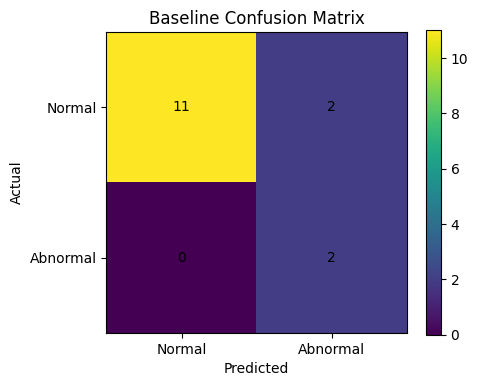

In [18]:
cm_baseline = confusion_matrix(y_test, baseline_pred)

plt.figure(figsize=(5, 4))
plt.imshow(cm_baseline, interpolation="nearest")
plt.title("Baseline Confusion Matrix")
plt.colorbar()
plt.xticks([0, 1], ["Normal", "Abnormal"])
plt.yticks([0, 1], ["Normal", "Abnormal"])
plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(cm_baseline.shape[0]):
    for j in range(cm_baseline.shape[1]):
        plt.text(j, i, cm_baseline[i, j], ha="center", va="center")

plt.tight_layout()
plt.savefig("figures/figure_2_baseline_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

## 13. Select sensitive features for encryption

For the privacy-preserving prototype, the following features are encrypted:
- `Income`
- `Heart Rate`
- `Oxygen Level Numeric`

These are financially and medically sensitive features and are therefore appropriate candidates for encryption.

In [19]:
sensitive_features = ["Income", "Heart Rate", "Oxygen Level Numeric"]
sensitive_idx = [feature_names.index(col) for col in sensitive_features]
public_idx = [i for i in range(len(feature_names)) if i not in sensitive_idx]

X_train_sensitive = X_train_proc[:, sensitive_idx]
X_test_sensitive = X_test_proc[:, sensitive_idx]
X_train_public = X_train_proc[:, public_idx]
X_test_public = X_test_proc[:, public_idx]

print("Sensitive encrypted features:", sensitive_features)
print("Number of encrypted features:", len(sensitive_idx))
print("Number of remaining public features:", len(public_idx))

Sensitive encrypted features: ['Income', 'Heart Rate', 'Oxygen Level Numeric']
Number of encrypted features: 3
Number of remaining public features: 55


## 14. Generate Paillier keys and encrypt the sensitive data

This step generates a Paillier public/private key pair and encrypts the selected sensitive features.

**Practical note:**  
The key length is set to `128` bits for a lightweight classroom demo so the notebook runs faster.  
For stronger security in real systems, use a much larger key such as 1024 bits or 2048 bits.

In [20]:
public_key, private_key = paillier.generate_paillier_keypair(n_length=128)

X_train_sensitive_enc = [
    [public_key.encrypt(float(value)) for value in row]
    for row in X_train_sensitive
]

X_test_sensitive_enc = [
    [public_key.encrypt(float(value)) for value in row]
    for row in X_test_sensitive
]

print("Example encrypted value:")
print(X_train_sensitive_enc[0][0])

Example encrypted value:


## 15. Save a new encrypted dataset

This cell creates a new CSV file representing the encrypted version of the sensitive features.  
The ciphertext and exponent are saved as strings so the file can be included in the assignment deliverables.

In [21]:
encrypted_export = df_model.copy()

# Rebuild processed sensitive features for the full dataset
X_all_proc = preprocessor.transform(X)
X_all_proc = np.asarray(X_all_proc, dtype=float)

for feature in sensitive_features:
    idx = feature_names.index(feature)
    encrypted_values = [public_key.encrypt(float(v)) for v in X_all_proc[:, idx]]
    encrypted_export[f"{feature}_ciphertext"] = [str(ev.ciphertext()) for ev in encrypted_values]
    encrypted_export[f"{feature}_exponent"] = [ev.exponent for ev in encrypted_values]

# Remove plaintext versions of the protected fields from the exported dataset
encrypted_export = encrypted_export.drop(columns=sensitive_features)

encrypted_dataset_path = "outputs/encrypted_dataset.csv"
encrypted_export.to_csv(encrypted_dataset_path, index=False)

print("Encrypted dataset saved to:", encrypted_dataset_path)
display(encrypted_export.head())

Encrypted dataset saved to: outputs/encrypted_dataset.csv


,Country,Sex,Marital Status,Education,Loan,House Status,Blood Type,Medical Procedure,Smoking,Alcohol Consumption,...,Tumor Condition,Age,Systolic BP,Diastolic BP,Income_ciphertext,Income_exponent,Heart Rate_ciphertext,Heart Rate_exponent,Oxygen Level Numeric_ciphertext,Oxygen Level Numeric_exponent
0,USA,Male,Married,Bachelor's Degree,Yes,Own,O+,Appendectomy,No,No,...,Normal,40.5,120,80.0,3567236659480261300299496837058379363544180493...,-14,3114162082667698492476935560892555315898824470...,-15,2058668409816080837545022420078151781498794322...,-14
1,Canada,Female,Single,Master's Degree,No,Rent,A-,Laser Eye Surgery,No,Yes,...,Normal,35.1,110,70.0,3727501242459422793084006183166312219025810839...,-14,9846154401602404499836202789465995102747672649...,-13,3349877499235579341514817843466561725147858526...,-13
2,UK,Male,Divorced,High School Diploma,Yes,Own,B+,Colonoscopy,No,Yes,...,Abnormal,47.8,130,85.0,8760324099557391697385464894184021963065168623...,-13,3672101487072125272422603135577607381929941080...,-14,1769252977766020379034189016372228450402375750...,-14
3,Australia,Female,Married,Associate's Degree,No,Own,AB-,Mammogram,No,No,...,Normal,43.3,115,75.0,3031097820268499832856527350872340624410517007...,-13,2833934083213499570806484291406644661439916733...,-14,2999105429488622531055155056553413302237695509...,-13
4,USA,Male,Single,Some College,No,Rent,O-,Dental Cleaning,Yes,Yes,...,Normal,30.5,125,80.0,2965099931599536832539862081034961852665545560...,-13,9857210583309482892550016927352319441581186656...,-13,4363070791106804373380748346238052978283408919...,-14


## 16. Define a lightweight homomorphic-encryption logistic regression prototype

This custom model demonstrates a privacy-preserving workflow:
- public features remain in plaintext
- selected sensitive features remain encrypted during secure linear computation
- Paillier homomorphic addition and scalar multiplication are used in the encrypted part of the score calculation

This is a prototype for academic demonstration rather than a production-grade encrypted learning system.

In [22]:
class HELinearLogisticRegression:
    def __init__(self, learning_rate=0.15, epochs=80, reg_lambda=0.01, random_state=42):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.reg_lambda = reg_lambda
        self.random_state = random_state
        self.loss_history = []

    @staticmethod
    def _sigmoid(z):
        z = np.clip(z, -20, 20)
        return 1 / (1 + np.exp(-z))

    def fit(self, X_public, X_sensitive_plain, X_sensitive_enc, y, public_key, private_key):
        rng = np.random.default_rng(self.random_state)

        n_samples = X_public.shape[0]
        n_public = X_public.shape[1]
        n_sensitive = X_sensitive_plain.shape[1]

        self.w_public = rng.normal(0, 0.01, size=n_public)
        self.w_sensitive = rng.normal(0, 0.01, size=n_sensitive)
        self.bias = 0.0
        self.loss_history = []

        for epoch in range(self.epochs):
            z_all = np.zeros(n_samples)

            for i in range(n_samples):
                enc_sum = public_key.encrypt(0.0)

                for enc_x, w in zip(X_sensitive_enc[i], self.w_sensitive):
                    enc_sum += enc_x * float(w)

                sensitive_part = private_key.decrypt(enc_sum)
                public_part = float(np.dot(X_public[i], self.w_public))
                z_all[i] = public_part + sensitive_part + self.bias

            p = self._sigmoid(z_all)
            error = p - y

            grad_public = (X_public.T @ error) / n_samples
            grad_sensitive = (X_sensitive_plain.T @ error) / n_samples
            grad_bias = error.mean()

            # Small L2 regularization
            grad_public += self.reg_lambda * self.w_public / n_samples
            grad_sensitive += self.reg_lambda * self.w_sensitive / n_samples

            self.w_public -= self.learning_rate * grad_public
            self.w_sensitive -= self.learning_rate * grad_sensitive
            self.bias -= self.learning_rate * grad_bias

            eps = 1e-9
            loss = -np.mean(y * np.log(p + eps) + (1 - y) * np.log(1 - p + eps))
            self.loss_history.append(loss)

        return self

    def predict_proba(self, X_public, X_sensitive_enc, public_key, private_key):
        n_samples = X_public.shape[0]
        z_all = np.zeros(n_samples)

        for i in range(n_samples):
            enc_sum = public_key.encrypt(0.0)

            for enc_x, w in zip(X_sensitive_enc[i], self.w_sensitive):
                enc_sum += enc_x * float(w)

            sensitive_part = private_key.decrypt(enc_sum)
            public_part = float(np.dot(X_public[i], self.w_public))
            z_all[i] = public_part + sensitive_part + self.bias

        p = self._sigmoid(z_all)
        return np.column_stack([1 - p, p])

    def predict(self, X_public, X_sensitive_enc, public_key, private_key, threshold=0.5):
        proba = self.predict_proba(X_public, X_sensitive_enc, public_key, private_key)[:, 1]
        return (proba >= threshold).astype(int)

## 17. Train the homomorphic encryption prototype

This step trains the privacy-preserving model using encrypted sensitive features and compares its runtime to the baseline.

In [23]:
he_model = HELinearLogisticRegression(
    learning_rate=0.15,
    epochs=80,
    reg_lambda=0.01,
    random_state=42
)

start_time = time.time()
he_model.fit(
    X_public=X_train_public,
    X_sensitive_plain=X_train_sensitive,
    X_sensitive_enc=X_train_sensitive_enc,
    y=y_train.to_numpy(),
    public_key=public_key,
    private_key=private_key
)
he_train_time = time.time() - start_time

he_pred = he_model.predict(
    X_public=X_test_public,
    X_sensitive_enc=X_test_sensitive_enc,
    public_key=public_key,
    private_key=private_key
)

he_metrics = {
    "Accuracy": accuracy_score(y_test, he_pred),
    "Precision": precision_score(y_test, he_pred, zero_division=0),
    "Recall": recall_score(y_test, he_pred, zero_division=0),
    "F1 Score": f1_score(y_test, he_pred, zero_division=0),
    "Training Time (s)": he_train_time
}

print("HE prototype metrics:")
for k, v in he_metrics.items():
    print(f"{k}: {v:.4f}" if isinstance(v, float) else f"{k}: {v}")

print("\nHE classification report:")
print(classification_report(y_test, he_pred, zero_division=0))

HE prototype metrics:
Accuracy: 0.8667
Precision: 0.5000
Recall: 1.0000
F1 Score: 0.6667
Training Time (s): 2.7590

HE classification report:
              precision    recall  f1-score   support

           0       1.00      0.85      0.92        13
           1       0.50      1.00      0.67         2

    accuracy                           0.87        15
   macro avg       0.75      0.92      0.79        15
weighted avg       0.93      0.87      0.88        15



## 18. Plot the encrypted-model confusion matrix

This figure can be placed in the report to compare encrypted-model performance with the baseline.

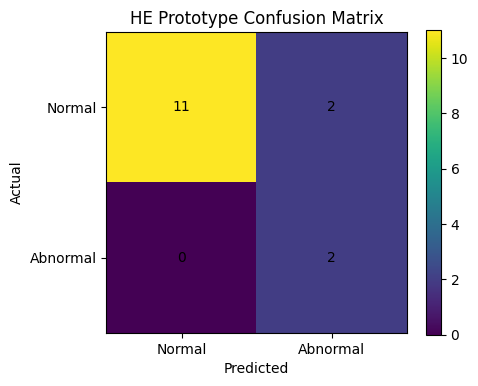

In [24]:
cm_he = confusion_matrix(y_test, he_pred)

plt.figure(figsize=(5, 4))
plt.imshow(cm_he, interpolation="nearest")
plt.title("HE Prototype Confusion Matrix")
plt.colorbar()
plt.xticks([0, 1], ["Normal", "Abnormal"])
plt.yticks([0, 1], ["Normal", "Abnormal"])
plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(cm_he.shape[0]):
    for j in range(cm_he.shape[1]):
        plt.text(j, i, cm_he[i, j], ha="center", va="center")

plt.tight_layout()
plt.savefig("figures/figure_3_he_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

## 19. Visualize HE model training loss

This plot helps explain convergence behavior and can be used in the report when discussing model behavior after encryption.

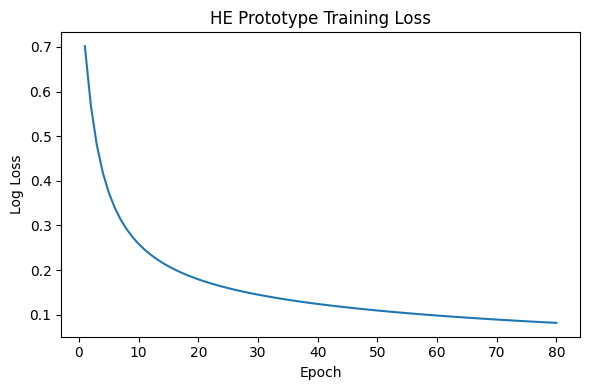

In [25]:
plt.figure(figsize=(6, 4))
plt.plot(range(1, len(he_model.loss_history) + 1), he_model.loss_history)
plt.title("HE Prototype Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Log Loss")
plt.tight_layout()
plt.savefig("figures/figure_4_he_training_loss.png", dpi=300, bbox_inches="tight")
plt.show()

## 20. Compare model performance side by side

This section creates a comparison table and a performance chart for the report.

In [26]:
results_df = pd.DataFrame([
    {
        "Model": "Plaintext Logistic Regression",
        "Accuracy": baseline_metrics["Accuracy"],
        "Precision": baseline_metrics["Precision"],
        "Recall": baseline_metrics["Recall"],
        "F1 Score": baseline_metrics["F1 Score"],
        "Training Time (s)": baseline_metrics["Training Time (s)"],
        "Privacy Level": "Low"
    },
    {
        "Model": "Paillier HE Prototype",
        "Accuracy": he_metrics["Accuracy"],
        "Precision": he_metrics["Precision"],
        "Recall": he_metrics["Recall"],
        "F1 Score": he_metrics["F1 Score"],
        "Training Time (s)": he_metrics["Training Time (s)"],
        "Privacy Level": "Higher"
    }
])

display(results_df)

results_df.to_csv("outputs/model_comparison_results.csv", index=False)
print("Comparison table saved to outputs/model_comparison_results.csv")

,Model,Accuracy,Precision,Recall,F1 Score,Training Time (s),Privacy Level
0,Plaintext Logistic Regression,0.866667,0.5,1.0,0.666667,0.032864,Low
1,Paillier HE Prototype,0.866667,0.5,1.0,0.666667,2.759015,Higher


Comparison table saved to outputs/model_comparison_results.csv


## 21. Plot the metric comparison chart

This figure is useful for the Results or Discussion section of the report.

<Figure size 800x500 with 0 Axes>

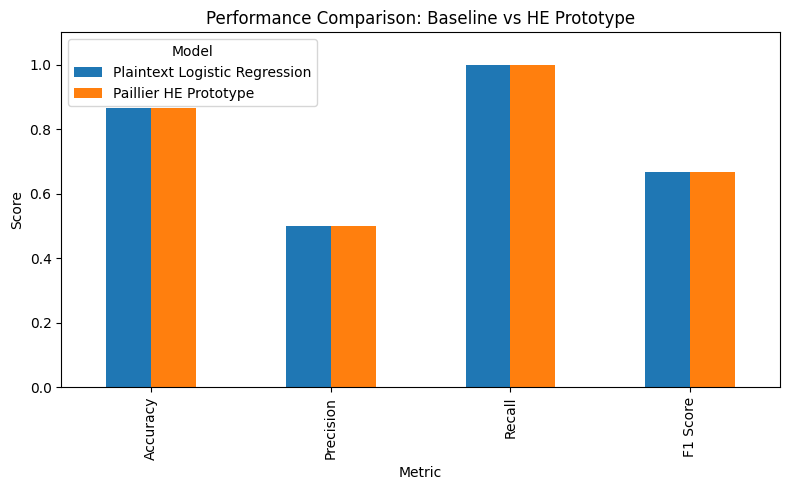

In [27]:
plot_df = results_df.set_index("Model")[["Accuracy", "Precision", "Recall", "F1 Score"]]

plt.figure(figsize=(8, 5))
plot_df.T.plot(kind="bar", figsize=(8, 5))
plt.title("Performance Comparison: Baseline vs HE Prototype")
plt.ylabel("Score")
plt.xlabel("Metric")
plt.ylim(0, 1.1)
plt.tight_layout()
plt.savefig("figures/figure_5_metric_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

## 22. Plot the runtime comparison chart

This figure shows the scalability tradeoff of encryption.  
The encrypted prototype is expected to be slower because homomorphic operations are computationally expensive.

<Figure size 600x400 with 0 Axes>

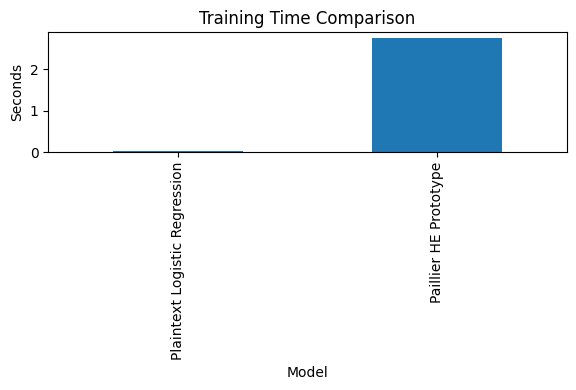

In [28]:
runtime_df = results_df.set_index("Model")[["Training Time (s)"]]

plt.figure(figsize=(6, 4))
runtime_df.plot(kind="bar", figsize=(6, 4), legend=False)
plt.title("Training Time Comparison")
plt.ylabel("Seconds")
plt.xlabel("Model")
plt.tight_layout()
plt.savefig("figures/figure_6_runtime_comparison.png", dpi=300, bbox_inches="tight")
plt.show()